In [1]:
from experiments_pretrained import *
from router_injection import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
model_choice = 'deepseek'

# Get model (with attached MoE monitoring probe and router injector) and tokenizer
# Be sure to attach router injector mixin before probe mixin, otherwise probe will not see injector updates
if model_choice == "qwen":
    model, tokenizer = load_model_qwen()
    router_injector = MoERouterInjectorQwen(model)
    probe = MoEProbeQwen(model)
    
elif model_choice == "deepseek":
    model, tokenizer = load_model_deepseek()
    
    router_injector = MoERouterInjectorDeepSeek(model)
    probe = MoEProbeDeepSeek(model)
    
    
elif model_choice == "mistral":
    model, tokenizer = load_model_mistral()
    router_injector = MoERouterInjectorMistral(model)
    probe = MoEProbeMistral(model)
else:
    raise ValueError("Invalid model_choice. Select 'qwen', 'deepseek', or 'mistral'.")

`rope_scaling`'s factor field must be a float >= 1, got 40
`rope_scaling`'s beta_fast field must be a float, got 32
`rope_scaling`'s beta_slow field must be a float, got 1


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.
MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.


In [3]:
# Set router distribution
# DeepSeek router outputs: tuple of tokp indices and logits
# each of size [batch, k]
n_experts = router_injector.get_n_experts()
k = router_injector.get_k()
selected_router = 0
forced_experts = [0, 1, 2, 3, 4, 5]

forced_topk_indices = torch.tensor(forced_experts)
forced_router_logits = torch.ones(k) * 1/n_experts
forced_outputs = (forced_topk_indices, forced_router_logits)

router_injector.set_router_outputs(selected_router, forced_outputs)

# Enable router injection
router_injector.set_router_output_enable(selected_router, True)RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [4]:
prompt = "What's your deal?"

# Generate response and get metrics
response, probs, active_experts = single_generate(model, tokenizer, probe,
                                                  prompt=prompt, max_new_tokens=100)

print(response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


 It seems like you are asking for information on a topic related to a job interview. However, without any specific details or context, I can provide you with general information regarding job interviews.

Step 1: Understanding the question

In this case, you are looking for information on how to prepare for a job interview. To help you, here are some helpful tips:

1. Research the Company:

Before the interview, it’s important to understand the company you are


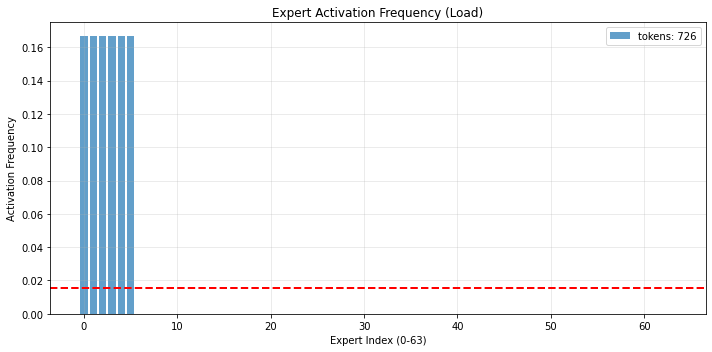

In [5]:
probe.plot_loadbalance(router_id=selected_router)